In [ ]:
# Setup
import os
import json
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
import multiprocessing as mp 
from tqdm.auto import tqdm
from PIL import Image
import time
from pathlib import Path

# IMPORTANT chart rules for this notebook (kept simple):
# - Use matplotlib (not seaborn)
# - Single plot per figure (no subplots)
# - Do not set any specific colors/styles unless you want to later

# Action vocabulary (ordered)
ACTION_LABELS = ["right", "down", "left", "up"]
SYSTEM_PROMPT="""You are a visuomotor policy for action prediction.
Given (1) the current observation as an image, (2) a goal as an image icon, and
(3) a behavior type, you must output
ONLY the next action as a canonical token from the environment's action space.

Rules:
- Return exactly one action string. No explanations, no punctuation.
- Prefer actions consistent with the stated behavior type. If ambiguous, choose the action
  that maximizes expected progress toward the goal under that behavior.
- Valid action set: {right, down, left, up}
"""

USER_PROMPT = """Task: Predict the next action.


Behavior type: {behavior_description}

Observation: see the image
Goal: see the place with white dot

Format:
Return ONE action token from the allowed set. No extra words.
"""

USER_PROMPT_DEPRECATED = """Task: Predict the next action.


Behavior type: {behavior_description}

Observation: see the first image
Goal: see the second image

Format:
Return ONE action token from the allowed set. No extra words.
"""

dataset_path = "/home/sukai/Project/chenyuan_project/new_multi_grid/data/training_data/actor_moves_dataset_single_image"

/home/sukai/anaconda3/envs/chenyuan2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Utility: plot a confusion matrix
def plot_confusion_matrix(cm, labels=ACTION_LABELS, title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    ax.set_title(title)
    plt.show()


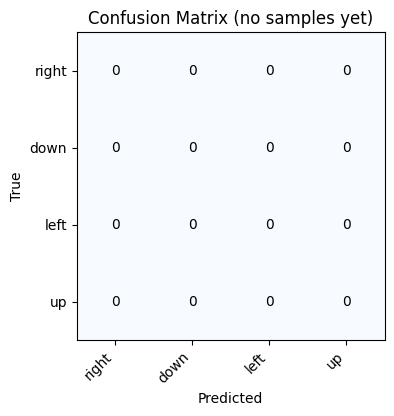

In [3]:
# All-zero confusion matrix (no samples)
cm = np.zeros((len(ACTION_LABELS), len(ACTION_LABELS)), dtype=int)
plot_confusion_matrix(cm, title="Confusion Matrix (no samples yet)")

In [4]:
# Load model and tokenizer
from unsloth import FastVisionModel
from transformers import AutoTokenizer
# lora_path = "/home/sukai/Project/chenyuan_project/new_multi_grid/outputs_noshuffle/checkpoint-13500"

# model, tokenizer = FastVisionModel.from_pretrained(
#         lora_path,
#         load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
#         use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
#     )

# # save to float 16
# model.save_pretrained_merged("/home/sukai/Project/chenyuan_project/new_multi_grid/data/trained_models/neuro_predictor_best_train_float16", tokenizer,)

# reload 

model, tokenizer = FastVisionModel.from_pretrained(
    "/home/sukai/Project/chenyuan_project/new_multi_grid/data/trained_models/neuro_predictor_float16",
    load_in_4bit=False,
    use_gradient_checkpointing="unsloth",
)

FastVisionModel.for_inference(model) # Enable for inference!


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.10.1: Fast Qwen2_5_Vl patching. Transformers: 4.54.1.
   \\   /|    NVIDIA A30-24C. Num GPUs = 1. Max memory: 23.996 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.0. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.59s/it]


Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear(in_features=1280, out_features=3840, bias=True)
            (proj): Linear(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear(in_features=3420, out_features=1280, bias=True)
            (act_fn): SiLU()

In [ ]:
def convert_to_conversation(sample):
    img_full_path = os.path.join(dataset_path, sample["image_path"])
    # image_obj = Image.open(img_full_path)
    # goal_icon_full_path = Path(img_full_path).with_name(f"icon_{Path(img_full_path).name}")
    # goal_icon_obj = Image.open(goal_icon_full_path)
    conversation = [
        {
            "role": "system",
            "content": [
                {"type": "text", "text": SYSTEM_PROMPT}
            ]
        },
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : USER_PROMPT.format(behavior_description=sample["behavior_description"])},
            {"type" : "image", "image" : f"file://{img_full_path}"},
            # {"type": "image", "image": f"file://{goal_icon_full_path}"}
        ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["action"]} ]
        },
    ]
    
    conversation_test = [
        {
            "role": "system",
            "content": [
                {"type": "text", "text": SYSTEM_PROMPT}
            ]
        },
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : USER_PROMPT.format(behavior_description=sample["behavior_description"])},
            {"type" : "image", "image" : f"file://{img_full_path}"},
            # {"type": "image", "image": f"file://{goal_icon_full_path}"}
            # {"type" : "image", "image" : image_obj},
            # {"type": "image", "image": goal_icon_obj}
        ]
        }
    ]
    
    
    return { "messages" : conversation }, {"messages" : conversation_test }, sample["action"], sample["behavior_description"]

In [6]:
# Load test data
test_dataset = load_dataset(dataset_path, split="test")
a = list(test_dataset)
    
with mp.Pool(16) as pool:
    # Use tqdm to visualize progress
    converted_dataset = list(
        tqdm(pool.imap(convert_to_conversation, a), total=len(a))
    )

# currently they are in zip form, split them
converted_full_dataset = []
converted_eval_dataset = []
converted_action_dataset  = [] 
converted_behavior_dataset = []

for item in converted_dataset:
    converted_full_dataset.append(item[0])
    converted_eval_dataset.append(item[1])
    converted_action_dataset.append(item[2])
    converted_behavior_dataset.append(item[3])

100%|██████████| 13789/13789 [00:01<00:00, 10820.83it/s]


In [7]:
# # only pick the first 1000 of the data 
# seleted_indices = random.sample(range(len(converted_eval_dataset)), k=1000)
# converted_eval_dataset = [converted_eval_dataset[i] for i in seleted_indices]
# converted_action_dataset = [converted_action_dataset[i] for i in seleted_indices]
# converted_behavior_dataset = [converted_behavior_dataset[i] for i in seleted_indices]


In [8]:
def pick_action(text: str) -> str:
    """Return the first allowed action found; fallback to 'right'."""
    s = text.lower().strip()
    # prefer exact token match in split words
    words = s.replace(",", " ").split()
    for a in ACTION_LABELS:
        if a in words:
            return a
    # fallback: substring search
    for a in ACTION_LABELS:
        if a in s:
            return a
    print("Warning: could not find action in model output:", text)
    return 'right'
    raise ValueError(f"Unknown action: {text}")
    return "right"

In [9]:
cm = np.zeros((len(ACTION_LABELS), len(ACTION_LABELS)), dtype=int)
PICK_ACTION_FROM_GENERATION = True 
total_guesses = 0
right_guesses = 0
inputs_collection = []
BATCH_SIZE = 1  # set your batch size here

pbar = tqdm(total=len(converted_eval_dataset), desc="Accuracy: 0.00% (0/0)")

top_k_data_dict = dict()
eval_info_dict = dict()

for start in range(0, len(converted_eval_dataset), BATCH_SIZE):
    batch = converted_eval_dataset[start:start + BATCH_SIZE]

    # Build batch
    images, texts, true_actions = [], [], []
    t0 = time.time()
    for j, sample in enumerate(batch):
        messages = sample["messages"]
        if isinstance(messages[-1]["content"][-2]["image"], str):
            img_path = messages[-1]["content"][-2]["image"].replace("file://", "")
            # images.append(Image.open(img_path).convert("RGB"))
            images.append(np.asarray(Image.open(img_path).convert("RGB")))
            
        else:
            images.append(messages[-1]["content"][-2]["image"].convert("RGB"))
            
        if isinstance(messages[-1]["content"][-1]["image"], str):
            goal_icon_path = messages[-1]["content"][-1]["image"].replace("file://", "")
            # images.append(Image.open(goal_icon_path).convert("RGB"))
            images.append(np.asarray(Image.open(goal_icon_path).convert("RGB")))
        else:
            images.append(messages[-1]["content"][-1]["image"].convert("RGB"))
        texts.append(tokenizer.apply_chat_template(messages, add_generation_prompt=True))
        true_actions.append(converted_action_dataset[start + j])  # keep alignment
        
    # Tokenize as a batch (padding=True is important)
    inputs = tokenizer(
        images,
        texts,
        add_special_tokens=False,
        padding=True,
        return_tensors="pt",
    ).to("cuda")
    
    # print(f"Processed batch [{start}:{start+len(batch)}] in {time.time() - t0:.2f}s")
    # Batched generation
    with torch.inference_mode():
        t1 = time.time()
        
        out = model.generate(
            **inputs,
            use_cache=False,
            do_sample=False,                 # greedy = slightly faster
            num_beams=1,
            max_new_tokens=1000,
            pad_token_id=tokenizer.eos_token_id,
            return_dict_in_generate=True,    # so we can access .sequences
        )
        # print(f"Generated batch in {time.time() - t1:.2f}s")
        seqs = out.sequences  # shape: [B, max_prompt_len + gen_len]
        prompt_len = inputs["input_ids"].shape[1]  # padded max prompt length
        gen_only = seqs[:, prompt_len:]
        decoded = tokenizer.batch_decode(gen_only, skip_special_tokens=True)
        
        
        logits = model(**inputs).logits[:, -1, :]  # Logits for next token
        prob = torch.softmax(logits, dim=-1)
        topk = torch.topk(prob, k=5) # shape: [B, 5]
        top_tokens = topk.indices
        top_probs = topk.values
        # print it with the true action
        for j in range(len(batch)):
            true_action = true_actions[j]
            # print(f"True action: {true_action}")
            for idx, (tok, p) in enumerate(zip(top_tokens[j], top_probs[j])):
                # print(f"Top {idx + 1}: {tokenizer.decode(tok)}, {float(p)}")
                # save info to dict
                id_key = start + j
                if id_key not in top_k_data_dict:
                    top_k_data_dict[id_key] = []
                top_k_data_dict[id_key].append( (tokenizer.decode(tok), float(p)) )
                
            # # another way to generate (just get the logits of the required actions)
            # all_action_ids = [tokenizer.tokenizer.convert_tokens_to_ids(a) for a in ACTION_LABELS]
            # action_logits = logits[:, all_action_ids]  # shape [B, 4]
            # action_prob = torch.softmax(action_logits, dim=-1)
            # for a_idx, a in enumerate(ACTION_LABELS):
            #     print(f"Action {a}: prob {float(action_prob[j, a_idx])}")

        
    # Evaluate predictions
    pred_action_lst = [] 
    for j, pred_text in enumerate(decoded):
        # print(f"Id: {start + j}, Predicted text: {pred_text}, True action: {true_actions[j]}")
        pred_action = pick_action(pred_text)
        pred_action_lst.append(pred_action)
        # true action id (by substring match to be robust to variants)
        true_str = true_actions[j].lower()
        true_id = next(i for i, a in enumerate(ACTION_LABELS) if a in true_str)
        pred_id = ACTION_LABELS.index(pred_action)

        cm[true_id, pred_id] += 1
        total_guesses += 1
        right_guesses += int(true_id == pred_id)
        
        # save to eval info dict
        if (start + j) not in eval_info_dict:
            eval_info_dict[start + j] = dict()
        # save true and pred action, and behavior type
        eval_info_dict[start + j]["true_action"] = true_actions[j]
        if PICK_ACTION_FROM_GENERATION:
            eval_info_dict[start + j]["pred_action"] = pred_action
        else:
            # use the top-1 from the allowed actions
            top1_action = top_k_data_dict[start + j][0][0]
            # preprocess and assert it is in the allowed set
            top1_action = pick_action(top1_action)
            eval_info_dict[start + j]["pred_action"] = top1_action
        eval_info_dict[start + j]["behavior_type"] = converted_behavior_dataset[start + j]

    acc = (right_guesses / total_guesses) if total_guesses else 0.0
    pbar.set_description(f"Accuracy: {acc*100:.2f}% ({right_guesses}/{total_guesses})")
    pbar.update(len(batch))

pbar.close()




Accuracy: 77.62% (10703/13789): 100%|██████████| 13789/13789 [1:23:43<00:00,  2.74it/s]


In [10]:
# val best model acc on test set from direct generation is around 77%
# val best model acc on test set with top 1 from allowed actions is around 77%
# train best model acc on test set is around ... 74%
action_set = set(converted_action_dataset)

In [11]:
action_set

{'down', 'left', 'right', 'up'}

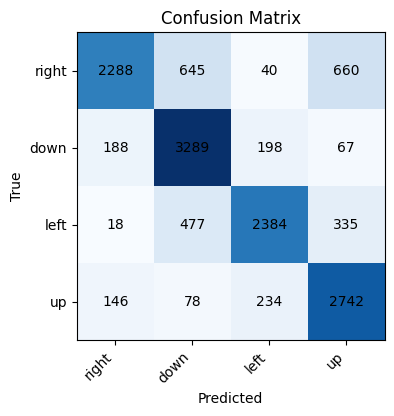

In [12]:
plot_confusion_matrix(cm, title="Confusion Matrix")

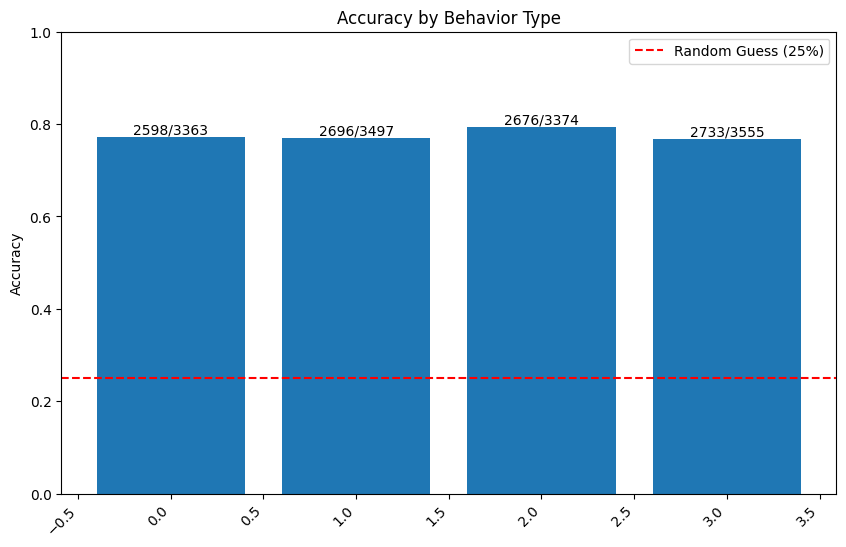

In [13]:
# analyze eval_info_dict, draw bar plot of success rate by behavior type
# each bar is a behavior type, height is accuracy
behavior_types = list(set(converted_behavior_dataset))
behavior_types.sort()
behavior_acc = {bt: [0, 0] for bt in behavior_types} # [correct, total]
for v in eval_info_dict.values():
    bt = v["behavior_type"]
    behavior_acc[bt][1] += 1
    if v["true_action"] == v["pred_action"]:
        behavior_acc[bt][0] += 1
# plot
plt.figure(figsize=(10, 6))
bars = plt.bar(behavior_acc.keys(), [c / t if t > 0 else 0 for c, t in behavior_acc.values()])
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Accuracy by Behavior Type")
# add text labels
for bar, (c, t) in zip(bars, behavior_acc.values()):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{c}/{t}", ha="center", va="bottom")
# After plotting the bars
plt.axhline(0.25, color='red', linestyle='--', label='Random Guess (25%)')  # Add reference line
plt.legend()  # To display the legend explaining the dashed line
plt.show()

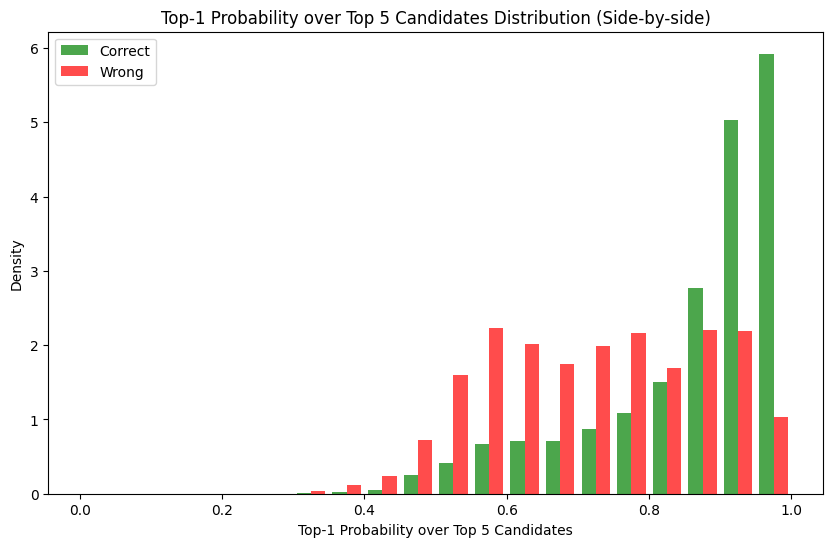

In [14]:
# calculate the confidence
# calculate the top k probability mean when the prediction is correct and when it is wrong
correct_top1_probs = []
wrong_top1_probs = []
for idx, topk_list in top_k_data_dict.items():
    true_action = eval_info_dict[idx]["true_action"]
    pred_action = eval_info_dict[idx]["pred_action"]
    top1_action, top1_prob = topk_list[0]
    if true_action == pred_action:
        correct_top1_probs.append(top1_prob)
    else:
        wrong_top1_probs.append(top1_prob)
        
# plot 
bins = np.linspace(0, 1, 21)  # Define common bins

# Calculate histogram data without plotting yet
correct_counts, _ = np.histogram(correct_top1_probs, bins=bins, density=True)
wrong_counts, _ = np.histogram(wrong_top1_probs, bins=bins, density=True)

width = (bins[1] - bins[0]) * 0.4  # Bar width (less than bin width)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Shift bin positions for side-by-side bars
correct_pos = bin_centers - width / 2
wrong_pos = bin_centers + width / 2

plt.figure(figsize=(10, 6))
plt.bar(correct_pos, correct_counts, width=width, alpha=0.7, label='Correct', color='g')
plt.bar(wrong_pos, wrong_counts, width=width, alpha=0.7, label='Wrong', color='r')

plt.xlabel('Top-1 Probability over Top 5 Candidates')
plt.ylabel('Density')
plt.title('Top-1 Probability over Top 5 Candidates Distribution (Side-by-side)')
plt.legend()
plt.show()

In [16]:
def calculate_threshold_using_conformal_prediction(probs, error_rate=0.1):
    """Calculate threshold using conformal prediction."""
    sorted_probs = sorted(probs)
    n = len(sorted_probs)
    # The (1 - error_rate) quantile index
    k = int(np.ceil((1 - error_rate) * (n + 1))) - 1
    k = min(max(k, 0), n - 1)  # Ensure k is within bounds
    threshold = sorted_probs[k]
    return threshold

# calculate threshold for 10% error rate
threshold_10 = calculate_threshold_using_conformal_prediction(wrong_top1_probs, error_rate=0.1)
threshold_5 = calculate_threshold_using_conformal_prediction(wrong_top1_probs, error_rate=0.05)
print(f"Threshold for 10% error rate: {threshold_10}")
print(f"Threshold for 5% error rate: {threshold_5}")

Threshold for 10% error rate: 0.9296875
Threshold for 5% error rate: 0.953125


In [15]:
# check when answer is wrong, the second most probable action is correct
second_correct = 0
second_total = 0
for idx, topk_list in top_k_data_dict.items():
    true_action = eval_info_dict[idx]["true_action"]
    pred_action = eval_info_dict[idx]["pred_action"]
    if true_action != pred_action:
        second_total += 1
        # check if true action is in top 2
        top2_actions = [a for a, p in topk_list[:2]]
        if true_action in top2_actions:
            # print(f"Index {idx}: True action '{true_action}' found in top 2 predictions {top2_actions}")
            second_correct += 1

# print the result
print(f"Second chance accuracy: {second_correct}/{second_total} = {second_correct/second_total*100:.2f}%")
print("Second chance accracy means we measure if the true action is in the top 2 predictions when the top 1 prediction is wrong.")
print("Random guess accuracy is 1 / (4 - 1) = 33.33% since we know the top 1 prediction is wrong.and we have 3 remaining actions.")

Second chance accuracy: 2710/3086 = 87.82%
Second chance accracy means we measure if the true action is in the top 2 predictions when the top 1 prediction is wrong.
Random guess accuracy is 1 / (4 - 1) = 33.33% since we know the top 1 prediction is wrong.and we have 3 remaining actions.


In [14]:
list(eval_info_dict.values())[0]

{'true_action': 'down', 'pred_action': 'left', 'behavior_type': '3'}

## Obversation 
1. it appears to to be overfit to the forward action

## Suggestions 
1. consider balancing the dataset by augmenting underrepresented actions.

## Relative Probs + Metrics

In [8]:
import time, math, torch, numpy as np
from PIL import Image
from tqdm.auto import tqdm
from copy import deepcopy

In [9]:
FastVisionModel.for_inference(model)
torch.set_grad_enabled(False)

In [23]:
DEVICE = "cuda"
ACTIONS = ["forward","left","right"]
BATCH_SIZE = 4
METHOD = "next_token" # choose: "next_token" (fast) or "sequence_ce" (accurate)

In [32]:
def strip_to_user_only(messages):
    """Keep system + user turns; drop assistant turn if present."""
    out = []
    for turn in messages:
        if turn["role"] == 'system':
            out.append(turn)  # keep system prompt as is
        
        elif turn["role"] == "user":
            local_turn = {
                'role': 'user',
                'content': []
            }
            # remove image key and image path pair
            for content in turn["content"]:
                if content.get("type") != "image":
                    local_turn["content"].append(content)
                else:
                    local_turn["content"].append({
                        'type': 'image',
                    })
            out.append(local_turn)
            
    return out

def get_image_path_from_messages(messages):
    # assumes the user turn has the image as last content
    for turn in reversed(messages):
        if turn["role"] == "user":
            for c in reversed(turn["content"]):
                if c.get("type") == "image":
                    return c["image"].replace("file://","")
    raise ValueError("No image found in messages!")

def true_id_from_text(s):
    s = s.lower()
    for i, a in enumerate(ACTIONS):
        if a in s:
            return i
    raise ValueError(f"True action not in allowed set: {s}")

# ---------- Method 1: Next-token probabilities ----------
# Uses only the FIRST token of each action (good if actions are single-token)
# Compute per-sample first-token ID sets under the *exact* prefix
def first_token_id_sets_under_prefix(tokenizer, prefix_text, actions):
    prefix_ids = tokenizer(None, prefix_text, add_special_tokens=False).input_ids
    id_sets = []
    for a in actions:
        cand = set()
        for variant in (" " + a, a, "\n" + a):
            enc = tokenizer(None, prefix_text + variant, add_special_tokens=False).input_ids
            # if len(enc) > len(prefix_ids):
            cand.add(enc[len(prefix_ids)])  # first *new* token after the prefix
        if not cand:
            raise ValueError(f"Could not derive first token(s) for action '{a}' in context.")
        id_sets.append(sorted(cand))
    return id_sets  # list[list[int]] aligned with actions


In [33]:
def next_token_probs_batch(samples):
    """Return probs [B,3] by marginalizing over all plausible first-token IDs per action."""
    images, texts = [], []
    for s in samples:
        msgs = strip_to_user_only(s["messages"])
        text = tokenizer.apply_chat_template(msgs, add_generation_prompt=True)
        texts.append(text)
        img_path = get_image_path_from_messages(s["messages"])
        images.append(Image.open(img_path).convert("RGB"))

    inputs = tokenizer(images, texts, add_special_tokens=False, padding=True, return_tensors="pt").to(DEVICE)

    with torch.inference_mode():
        out = model(**inputs)
        last_logits = out.logits[:, -1, :]  # [B, V]

    # For each sample, compute action scores via log-sum-exp over that sample's ID sets
    probs_list = []
    for i, prefix_text in enumerate(texts):
        id_sets = first_token_id_sets_under_prefix(tokenizer, prefix_text, ACTIONS)

        # score_j = log( sum_{t in set_j} exp(logit_t) )
        scores = []
        for ids in id_sets:
            idx = torch.tensor(ids, device=DEVICE, dtype=torch.long)
            scores.append(torch.logsumexp(last_logits[i, idx], dim=0))
        scores = torch.stack(scores, dim=0)           # [3]
        probs  = torch.softmax(scores, dim=-1)        # [3]
        probs_list.append(probs)

    return torch.stack(probs_list, dim=0)             # [B, 3]

In [34]:
# ---------- Method 2: Full phrase log-likelihood via masked CE ----------
# More faithful when an action spans multiple tokens.
def question_token_lengths_for_batch(base_msgs_list):
    lens = []
    for msgs in base_msgs_list:
        # tokens up to the assistant generation point
        toks = tokenizer.apply_chat_template(msgs, tokenize=True, add_generation_prompt=True)
        lens.append(len(toks))
    return lens

def build_inputs_with_answer_batch(base_msgs_list, images, answer_text):
    """Append assistant answer; return tokenizer outputs for the whole conversation."""
    texts = []
    for msgs in base_msgs_list:
        conv = list(msgs) + [{"role": "assistant", "content":[{"type":"text","text": answer_text}]}]
        txt = tokenizer.apply_chat_template(conv, tokenize=False, add_generation_prompt=False)
        texts.append(txt)
    return tokenizer(images, texts, add_special_tokens=False, padding=True, return_tensors="pt").to(DEVICE)

def sequence_ce_probs_batch(samples):
    """Compute per-action sequence log-probs and softmax them to get relative probs."""
    # 1) Prepare base conversations (system+user) and images once
    base_msgs_list, images = [], []
    for s in samples:
        m = strip_to_user_only(s["messages"])
        base_msgs_list.append(m)
        img_path = get_image_path_from_messages(s["messages"])
        images.append(Image.open(img_path).convert("RGB"))

    # 2) Token lengths at the assistant start (per sample)
    qlens = question_token_lengths_for_batch(base_msgs_list)

    # 3) For each action, append as assistant, compute NLL per sample
    nlls = []  # list of tensors [B]
    for a in ACTIONS:
        inputs = build_inputs_with_answer_batch(base_msgs_list, images, a)
        attn = inputs["attention_mask"]  # [B, T]
        with torch.inference_mode():
            out = model(**inputs)
            logits = out.logits  # [B, T, V]

        # shift for CE: predict token t from position t-1 logits
        shift_logits = logits[:, :-1, :]            # [B, T-1, V]
        shift_labels = inputs.input_ids[:, 1:]      # [B, T-1]
        shift_attn   = attn[:, 1:]                  # [B, T-1]

        # build mask for assistant tokens only (after qlen)
        B, Tm1 = shift_labels.size()
        idx = torch.arange(Tm1, device=DEVICE).unsqueeze(0).expand(B, -1)  # [B, T-1]
        qlen_tensor = torch.tensor([ql - 1 for ql in qlens], device=DEVICE).unsqueeze(1)  # align to shift
        # valid positions: >= qlen-1 (i.e., assistant tokens) AND attention=1
        mask = (idx >= qlen_tensor) & (shift_attn.bool())

        # log-softmax
        log_probs = torch.log_softmax(shift_logits, dim=-1)                # [B, T-1, V]
        # gather per-token log-prob of the true next token
        lp = log_probs.gather(dim=-1, index=shift_labels.unsqueeze(-1)).squeeze(-1)  # [B, T-1]
        lp_masked = lp.masked_fill(~mask, 0.0)

        # NLL per sample = -sum log-probs over assistant tokens
        n_tokens = mask.sum(dim=1).clamp_min(1)         # avoid div-by-zero
        nll = -lp_masked.sum(dim=1)                     # [B]
        nlls.append(nll)

    # 4) Convert NLLs to relative probabilities via softmax over negative NLL
    #    log p(action | x) ∝ -NLL(action)
    nlls = torch.stack(nlls, dim=1)  # [B, 3]
    probs = torch.softmax(-nlls, dim=1)
    return probs


In [35]:
# ---------- Evaluation loop (batched) ----------
def evaluate_probs_and_metrics(method="sequence_ce", batch_size=4):
    probs_all = []
    y_true = []

    pbar = tqdm(total=len(converted_eval_dataset), desc="Eval")
    for i in range(0, len(converted_eval_dataset), batch_size):
        batch = converted_eval_dataset[i:i+batch_size]
        if method == "next_token":
            probs = next_token_probs_batch(batch)          # [B,3]
        else:
            probs = sequence_ce_probs_batch(batch)         # [B,3]
        probs_all.append(probs.cpu())
        # collect true ids
        for j in range(len(batch)):
            y_true.append(true_id_from_text(converted_action_dataset[i+j]))
        pbar.update(len(batch))
    pbar.close()

    probs_all = torch.cat(probs_all, dim=0).to(torch.float).numpy()        # [N,3]
    y_true = np.array(y_true, dtype=int)                   # [N]
    y_pred = probs_all.argmax(axis=1)

    # Confusion matrix
    K = len(ACTIONS)
    cm = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    # Accuracy
    acc = (y_pred == y_true).mean()

    # Macro-F1
    f1s = []
    for k in range(K):
        tp = np.sum((y_pred == k) & (y_true == k))
        fp = np.sum((y_pred == k) & (y_true != k))
        fn = np.sum((y_pred != k) & (y_true == k))
        prec = tp / (tp + fp + 1e-12)
        rec  = tp / (tp + fn + 1e-12)
        f1 = 2 * prec * rec / (prec + rec + 1e-12)
        f1s.append(f1)
    macro_f1 = float(np.mean(f1s))

    # Log loss (cross-entropy)
    logloss = -np.log(np.clip(probs_all[np.arange(len(y_true)), y_true], 1e-12, 1.0)).mean()

    # Brier score (multi-class)
    onehot = np.eye(K)[y_true]
    # make sure probs_all shape is equal to onehot
    # squeeze helps
    try:
        probs_all = probs_all.squeeze()
        brier = np.mean(np.sum((probs_all - onehot) ** 2, axis=1))
    except Exception as e:
        print(e)
        
        return probs_all , y_true, None

    # Expected Calibration Error (ECE, 10 bins, max-prob as confidence)
    confidences = probs_all.max(axis=1)
    correctness = (y_pred == y_true).astype(float)
    bins = np.linspace(0.0, 1.0, 11)
    ece = 0.0
    for b0, b1 in zip(bins[:-1], bins[1:]):
        idx = (confidences >= b0) & (confidences < b1)
        if not np.any(idx):
            continue
        acc_bin = correctness[idx].mean()
        conf_bin = confidences[idx].mean()
        ece += (idx.mean()) * abs(acc_bin - conf_bin)

    metrics = {
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "log_loss": float(logloss),
        "brier": float(brier),
        "ece_10bins": float(ece),
        "confusion_matrix": cm,
    }
    return probs_all, y_true, metrics

In [36]:
probs, y_true, metrics = evaluate_probs_and_metrics(method=METHOD, batch_size=BATCH_SIZE)
print("Metrics:", {k: (v if k != "confusion_matrix" else "\n"+str(v)) for k, v in metrics.items()})

IndexError: list index out of range

In [24]:
probs_old , y_true_old, metrics_old = probs, y_true, metrics
print(probs[14])
print(y_true[0])

[0.33398438 0.33398438 0.33398438]
1


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Compute calibration bins + ECE (10 bins by default) ----
def compute_calibration(probs_all, y_true, n_bins=10):
    """
    probs_all: [N, K] predicted probabilities
    y_true:    [N] true class indices
    """
    probs_all = np.asarray(probs_all)
    y_true = np.asarray(y_true)
    y_pred = probs_all.argmax(axis=1)
    confidences = probs_all.max(axis=1)
    correctness = (y_pred == y_true).astype(float)

    # Bin edges and assignment
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    # np.digitize returns 0..n_bins-1 when using edges[1:-1]
    bin_ids = np.digitize(confidences, edges[1:-1], right=False)

    bin_acc   = np.zeros(n_bins, dtype=float)
    bin_conf  = np.zeros(n_bins, dtype=float)
    bin_count = np.zeros(n_bins, dtype=int)

    for b in range(n_bins):
        idx = (bin_ids == b)
        if np.any(idx):
            bin_acc[b]   = correctness[idx].mean()
            bin_conf[b]  = confidences[idx].mean()
            bin_count[b] = idx.sum()

    # ECE = sum_over_bins( (n_bin/N) * |acc_bin - conf_bin| )
    N = len(y_true)
    with np.errstate(divide='ignore', invalid='ignore'):
        ece = np.sum((bin_count / max(N, 1)) * np.abs(bin_acc - bin_conf))

    bin_centers = 0.5 * (edges[:-1] + edges[1:])
    return {
        "bin_centers": bin_centers,
        "bin_accuracy": bin_acc,
        "bin_confidence": bin_conf,
        "bin_count": bin_count,
        "ece": float(ece),
        "confidences": confidences,
        "correctness": correctness,  # 1 = correct, 0 = incorrect
        "y_pred": y_pred,
    }

# ---- 1) Reliability diagram (Accuracy vs Confidence) ----
def plot_reliability_diagram(calib, title_prefix="Calibration (10-bin ECE)"):
    centers   = calib["bin_centers"]
    acc       = calib["bin_accuracy"]
    count     = calib["bin_count"]
    mask      = count > 0  # only show bins that have data

    fig, ax = plt.subplots(figsize=(5, 5))
    # Perfect calibration line
    ax.plot([0, 1], [0, 1])
    # Empirical accuracy per bin
    ax.plot(centers[mask], acc[mask], marker="o")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"{title_prefix}: ECE={calib['ece']:.3f}")
    plt.show()

# ---- 2) Confidence histogram: correct vs incorrect ----
def plot_confidence_hist(calib, bins=20):
    conf = calib["confidences"]
    corr = calib["correctness"].astype(bool)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(conf[corr], bins=bins, alpha=0.6, label="correct")
    ax.hist(conf[~corr], bins=bins, alpha=0.6, label="incorrect")
    ax.set_xlabel("Confidence (max class probability)")
    ax.set_ylabel("Count")
    ax.set_title("Confidence distribution: correct vs incorrect")
    ax.legend()
    plt.show()

# ---- 3) Confidence boxplot: correct vs incorrect ----
def plot_confidence_boxplot(calib):
    conf = calib["confidences"]
    corr = calib["correctness"].astype(bool)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.boxplot([conf[corr], conf[~corr]], labels=["correct", "incorrect"], showfliers=False)
    ax.set_ylabel("Confidence (max class probability)")
    ax.set_title("Confidence by outcome")
    plt.show()


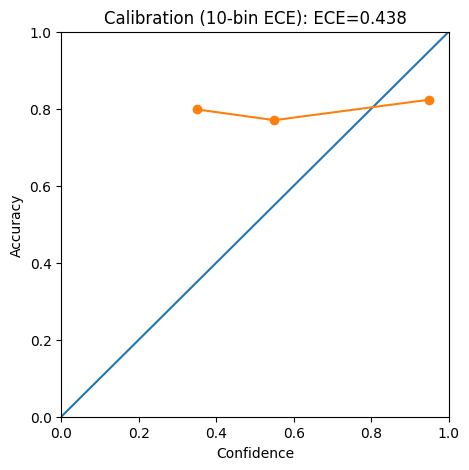

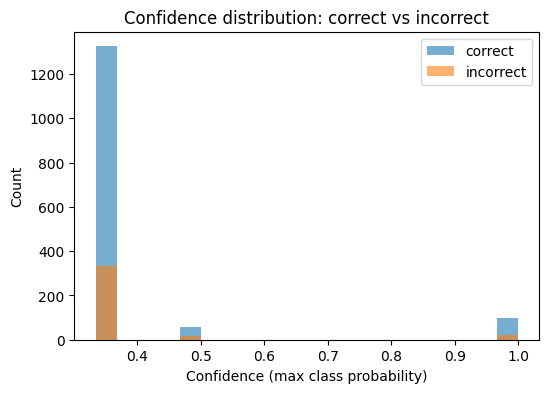

/tmp/ipykernel_1070437/3055727070.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([conf[corr], conf[~corr]], labels=["correct", "incorrect"], showfliers=False)


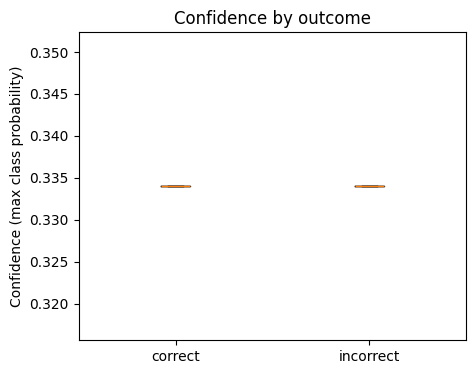

In [18]:
calib = compute_calibration(probs, y_true, n_bins=10)

plot_reliability_diagram(calib)       # accuracy vs confidence + ECE in title
plot_confidence_hist(calib, bins=20)  # distribution of confidences
plot_confidence_boxplot(calib)        # compact view: correct vs incorrect